In [53]:
from ultralytics import YOLO

print("Ultralytics imported successfully.")


Ultralytics imported successfully.


In [54]:
from ultralytics import YOLO

detector = YOLO("yolo11n.pt")

print("YOLO model loaded.")

YOLO model loaded.


In [55]:
traffic_image = "../data/raw/traffic_test.jpg"

results = detector(
    traffic_image,
    conf=0.40
)

print("Detection completed.")


image 1/1 c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\notebooks\..\data\raw\traffic_test.jpg: 640x448 6 persons, 6 cars, 1 traffic light, 162.1ms
Speed: 25.4ms preprocess, 162.1ms inference, 30.6ms postprocess per image at shape (1, 3, 640, 448)
Detection completed.


In [56]:
results[0].show()

In [57]:
result = results[0]

car_count = 0
person_count = 0

for box in result.boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    
    class_name = result.names[class_id]
    
    if class_name == "car":
        car_count += 1
        
    elif class_name == "person":
        person_count += 1

print("Cars detected:", car_count)
print("People detected:", person_count)

Cars detected: 6
People detected: 6


In [58]:
 for box in result.boxes:
    
    class_id = int(box.cls[0])
    class_name = result.names[class_id]
    confidence = float(box.conf[0])
    
    if class_name == "car":
        
        x1, y1, x2, y2 = map(
            int,
            box.xyxy[0].tolist()
        )
        
        print(
            f"Car | "
            f"Confidence: {confidence:.2f} | "
            f"Box: ({x1}, {y1}, {x2}, {y2})"
        )

Car | Confidence: 0.87 | Box: (1, 5565, 1403, 6953)
Car | Confidence: 0.85 | Box: (0, 5984, 981, 6957)
Car | Confidence: 0.81 | Box: (265, 5018, 1819, 6634)
Car | Confidence: 0.79 | Box: (1148, 4862, 2466, 6197)
Car | Confidence: 0.77 | Box: (0, 4435, 712, 5585)
Car | Confidence: 0.47 | Box: (2051, 3761, 2697, 4147)


In [59]:
from PIL import Image

image = Image.open(traffic_image).convert("RGB")

car_crops = []

for box in result.boxes:
    
    class_id = int(box.cls[0])
    class_name = result.names[class_id]
    
    if class_name == "car":
        
        x1, y1, x2, y2 = map(
            int,
            box.xyxy[0].tolist()
        )
        
        crop = image.crop((x1, y1, x2, y2))
        car_crops.append(crop)

print("Number of car crops:", len(car_crops))

Number of car crops: 6


In [60]:
def predict_pil_car_color(img):
    
    img = img.convert("RGB")
    img = img.resize(IMG_SIZE)
    
    image_array = np.array(
        img,
        dtype=np.float32
    ) / 255.0
    
    image_array = np.expand_dims(
        image_array,
        axis=0
    )
    
    probabilities = model.predict(
        image_array,
        verbose=0
    )[0]
    
    predicted_id = np.argmax(probabilities)
    
    predicted_label = id_to_label[predicted_id]
    
    confidence = probabilities[predicted_id]
    
    return predicted_label, confidence

In [64]:
from pathlib import Path

model_path = Path(
    r"C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\models\car_color_model.keras"
)

print("Exists:", model_path.exists())

if model_path.exists():
    print("Size:", model_path.stat().st_size / (1024 * 1024), "MB")

Exists: True
Size: 112.54460144042969 MB


In [65]:
import tensorflow as tf

model = tf.keras.models.load_model(model_path)

print("✅ Model loaded successfully")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

✅ Model loaded successfully
Input shape: (None, 224, 224, 3)
Output shape: (None, 15)


In [69]:
id_to_label = {
    0: "beige",
    1: "black",
    2: "blue",
    3: "brown",
    4: "gold",
    5: "green",
    6: "grey",
    7: "orange",
    8: "pink",
    9: "purple",
    10: "red",
    11: "silver",
    12: "tan",
    13: "white",
    14: "yellow"
}

In [70]:
for i, crop in enumerate(car_crops):
    
    color, confidence = predict_pil_car_color(crop)
    
    print(
        f"Car {i + 1}: "
        f"{color} "
        f"({confidence * 100:.2f}%)"
    )

Car 1: green (52.61%)
Car 2: green (62.79%)
Car 3: green (37.74%)
Car 4: orange (81.55%)
Car 5: black (88.54%)
Car 6: green (90.93%)


In [71]:
if color.lower() == "blue":
    box_color = (255, 0, 0)      # Red in BGR
else:
    box_color = (0, 0, 255)      # Blue in BGR

In [72]:
import cv2
import numpy as np
from PIL import Image
from pathlib import Path


def process_traffic_image(
    image_path,
    detector,
    color_model,
    img_size,
    id_to_label,
    confidence_threshold=0.40
):
    
    # -----------------------------------------
    # 1. Read image with OpenCV
    # -----------------------------------------
    image = cv2.imread(str(image_path))

    if image is None:
        raise FileNotFoundError(
            f"Could not read image: {image_path}"
        )

    # -----------------------------------------
    # 2. Detect objects with YOLO
    # -----------------------------------------
    results = detector(
        image,
        conf=confidence_threshold,
        verbose=False
    )

    result = results[0]

    car_count = 0
    person_count = 0

    car_results = []

    # -----------------------------------------
    # 3. Process detections
    # -----------------------------------------
    for box in result.boxes:

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = result.names[class_id]

        x1, y1, x2, y2 = map(
            int,
            box.xyxy[0].tolist()
        )

        # Make sure coordinates stay inside image
        h, w = image.shape[:2]

        x1 = max(0, min(x1, w - 1))
        y1 = max(0, min(y1, h - 1))
        x2 = max(0, min(x2, w - 1))
        y2 = max(0, min(y2, h - 1))

        # -------------------------------------
        # PERSON
        # -------------------------------------
        if class_name == "person":

            person_count += 1

            # Normal person box
            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                (0, 255, 255),
                2
            )

            cv2.putText(
                image,
                f"Person {confidence:.0%}",
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 255),
                2
            )

        # -------------------------------------
        # CAR
        # -------------------------------------
        elif class_name == "car":

            car_count += 1

            # Crop car
            car_crop = image[y1:y2, x1:x2]

            if car_crop.size == 0:
                continue

            # Convert BGR → RGB
            car_rgb = cv2.cvtColor(
                car_crop,
                cv2.COLOR_BGR2RGB
            )

            # Resize
            car_rgb = cv2.resize(
                car_rgb,
                img_size
            )

            # Normalize
            car_array = (
                np.asarray(
                    car_rgb,
                    dtype=np.float32
                ) / 255.0
            )

            # Add batch dimension
            car_array = np.expand_dims(
                car_array,
                axis=0
            )

            # ---------------------------------
            # Colour prediction
            # ---------------------------------
            probabilities = color_model.predict(
                car_array,
                verbose=0
            )[0]

            predicted_id = int(
                np.argmax(probabilities)
            )

            predicted_color = id_to_label[
                predicted_id
            ]

            color_confidence = float(
                probabilities[predicted_id]
            )

            # ---------------------------------
            # Internship rectangle rule
            # ---------------------------------
            if predicted_color.lower() == "blue":

                # RED rectangle — BGR
                box_color = (0, 0, 255)

            else:

                # BLUE rectangle — BGR
                box_color = (255, 0, 0)

            # Draw car rectangle
            cv2.rectangle(
                image,
                (x1, y1),
                (x2, y2),
                box_color,
                3
            )

            # Text
            label = (
                f"{predicted_color} "
                f"{color_confidence:.0%}"
            )

            cv2.putText(
                image,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.65,
                box_color,
                2
            )

            car_results.append({
                "color": predicted_color,
                "confidence": color_confidence,
                "box": (x1, y1, x2, y2)
            })

    # -----------------------------------------
    # 4. Summary information
    # -----------------------------------------

    cv2.rectangle(
        image,
        (10, 10),
        (330, 100),
        (0, 0, 0),
        -1
    )

    cv2.putText(
        image,
        f"Cars: {car_count}",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.75,
        (255, 255, 255),
        2
    )

    cv2.putText(
        image,
        f"People: {person_count}",
        (20, 75),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.75,
        (255, 255, 255),
        2
    )

    return image, car_count, person_count, car_results

In [90]:
from pathlib import Path

PROJECT_DIR = Path(
    r"C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI"
)

traffic_image = PROJECT_DIR / "data" / "raw" / "traffic_test.jpg"

print("Project path:", PROJECT_DIR)
print("Image path:", traffic_image)
print("Image exists:", traffic_image.exists())

Project path: C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI
Image path: C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\traffic_test.jpg
Image exists: True


In [91]:
results = detector(
    str(traffic_image),
    conf=0.40
)

print("Detection completed!")

image 1/1 C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\raw\traffic_test.jpg: 640x448 6 persons, 6 cars, 1 traffic light, 292.5ms
Speed: 90.5ms preprocess, 292.5ms inference, 32.9ms postprocess per image at shape (1, 3, 640, 448)
Detection completed!


In [92]:
processed_image, car_count, person_count, car_results = process_traffic_image(
    traffic_image,
    detector,
    model,
    IMG_SIZE,
    id_to_label
)

In [93]:
print("================================")
print("TRAFFIC ANALYSIS")
print("================================")

print("Cars detected   :", car_count)
print("People detected :", person_count)

print("\nCars:")

for i, car in enumerate(car_results, start=1):

    print(
        f"Car {i}: "
        f"{car['color']} "
        f"({car['confidence']:.2%})"
    )

TRAFFIC ANALYSIS
Cars detected   : 6
People detected : 6

Cars:
Car 1: green (60.38%)
Car 2: green (67.54%)
Car 3: green (39.56%)
Car 4: orange (71.61%)
Car 5: black (88.58%)
Car 6: green (99.60%)


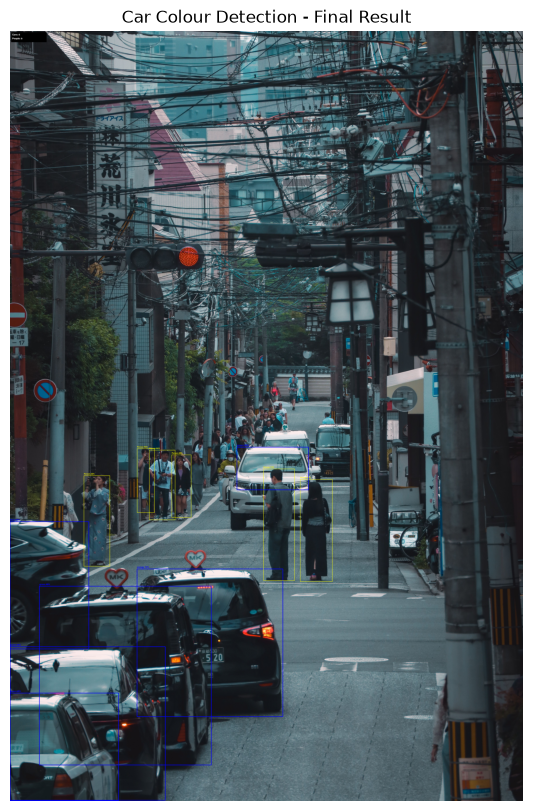

In [94]:
import matplotlib.pyplot as plt

display_image = cv2.cvtColor(
    processed_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(16, 10))
plt.imshow(display_image)
plt.axis("off")
plt.title("Car Colour Detection - Final Result")
plt.show()

In [95]:
output_dir = PROJECT_DIR / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

In [96]:
output_path = output_dir / "traffic_result.jpg"

cv2.imwrite(
    str(output_path),
    processed_image
)

print("Saved result:")
print(output_path)

Saved result:
C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\outputs\traffic_result.jpg


In [97]:
import sys

sys.path.append(str(PROJECT_DIR / "src"))

In [98]:
from detector import VehicleDetector
from color_classifier import CarColorClassifier
from pipeline import CarColorPipeline

In [100]:
import tensorflow as tf

color_model = tf.keras.models.load_model(
    PROJECT_DIR / "models" / "car_color_best.keras"
)

detector = VehicleDetector(
    model_path="yolo11n.pt",
    confidence=0.40
)

color_classifier = CarColorClassifier(
    model=color_model,
    img_size=(224, 224),
    id_to_label=id_to_label
)

pipeline = CarColorPipeline(
    detector=detector,
    color_classifier=color_classifier
)

print("Complete pipeline loaded successfully.")

Complete pipeline loaded successfully.


In [101]:
image = cv2.imread(
    str(PROJECT_DIR / "data" / "raw" / "traffic_test.jpg")
)

result = pipeline.process(image)

In [102]:
print("Cars:", result["car_count"])
print("People:", result["person_count"])

for i, car in enumerate(result["cars"], start=1):

    print(
        f"Car {i}: "
        f"{car['color']} "
        f"({car['confidence']:.2%})"
    )

Cars: 6
People: 6
Car 1: grey (32.18%)
Car 2: grey (31.32%)
Car 3: grey (32.93%)
Car 4: orange (76.59%)
Car 5: black (94.52%)
Car 6: green (94.11%)


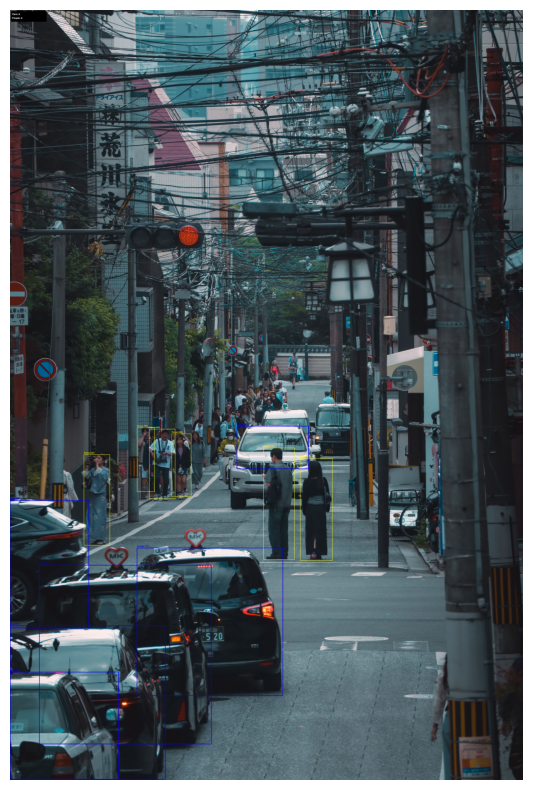

In [103]:
import matplotlib.pyplot as plt

display_image = cv2.cvtColor(
    result["image"],
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(16, 10))
plt.imshow(display_image)
plt.axis("off")
plt.show()

In [104]:
import sys
from pathlib import Path

PROJECT_DIR = Path(
    r"C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI"
)

sys.path.append(str(PROJECT_DIR / "src"))

In [105]:
import tensorflow as tf

from detector import VehicleDetector
from color_classifier import CarColorClassifier
from pipeline import CarColorPipeline
from config import IMG_SIZE, ID_TO_LABEL

In [107]:
color_model = tf.keras.models.load_model(
    PROJECT_DIR / "models" / "car_color_best.keras"
)

detector = VehicleDetector(
    model_path="yolo11n.pt",
    confidence=0.40
)

color_classifier = CarColorClassifier(
    model=color_model,
    img_size=IMG_SIZE,
    id_to_label=ID_TO_LABEL
)

pipeline = CarColorPipeline(
    detector=detector,
    color_classifier=color_classifier
)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [111]:
from pathlib import Path

print("PROJECT DIR:")
print(PROJECT_DIR)

print("\nDATA DIRECTORY:")
data_dir = PROJECT_DIR / "data"
print(data_dir)
print("Exists:", data_dir.exists())

if data_dir.exists():
    print("\nFolders/files inside data:")
    for item in data_dir.iterdir():
        print(" -", item.name, " [DIR]" if item.is_dir() else " [FILE]")

PROJECT DIR:
C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI

DATA DIRECTORY:
C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data
Exists: True

Folders/files inside data:
 - processed  [DIR]
 - raw  [DIR]
 - splits  [DIR]
 - test  [DIR]
 - test_images.jpg  [FILE]
 - train  [DIR]
 - val  [DIR]


In [112]:
import cv2
from pathlib import Path

TEST_IMAGE = PROJECT_DIR / "data" / "test_images.jpg"

OUTPUT_DIR = PROJECT_DIR / "outputs" / "test_results"
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Test image:", TEST_IMAGE)
print("Exists:", TEST_IMAGE.exists())

if TEST_IMAGE.exists():
    image = cv2.imread(str(TEST_IMAGE))

    if image is None:
        print("ERROR: Could not read the image.")
    else:
        print("Image loaded successfully!")
        print("Image shape:", image.shape)
else:
    print("ERROR: Test image not found.")
    

Test image: C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\test_images.jpg
Exists: True
Image loaded successfully!
Image shape: (5214, 3476, 3)


In [119]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# Step 70: Test image
TEST_IMAGE = PROJECT_DIR / "data" / "test" / "test_images.jpg"

print("Test image path:")
print(TEST_IMAGE)

print("\nExists:", TEST_IMAGE.exists())

if not TEST_IMAGE.exists():
    raise FileNotFoundError(
        f"Test image not found:\n{TEST_IMAGE}"
    )

# Load image
image = cv2.imread(str(TEST_IMAGE))

if image is None:
    raise ValueError("OpenCV could not read the test image.")

# Convert BGR → RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("\nImage loaded successfully!")
print("Image shape:", image.shape)
print("Image height:", image.shape[0])
print("Image width:", image.shape[1])

Test image path:
C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\test\test_images.jpg

Exists: True

Image loaded successfully!
Image shape: (5214, 3476, 3)
Image height: 5214
Image width: 3476


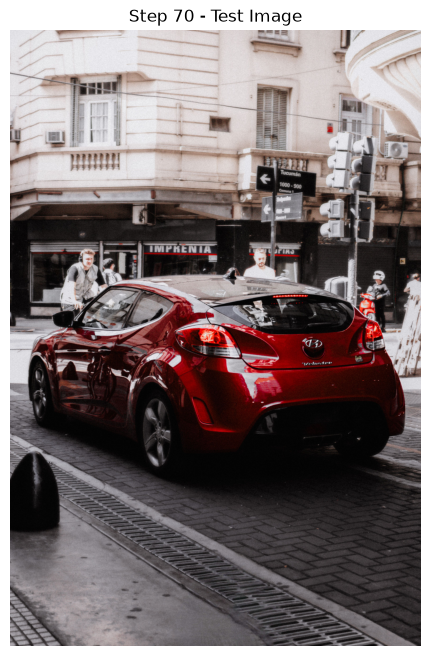

In [120]:
plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Step 70 - Test Image")
plt.show()

YOLO model:
C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\yolo26s.pt
Exists: True

STEP 71 — DETECTION RESULTS
Total detections: 13
1. PERSON          confidence=82.38% box=(3016, 2035, 3218, 2559)
2. PERSON          confidence=79.33% box=(1972, 1841, 2248, 2111)
3. PERSON          confidence=77.81% box=(422, 1849, 819, 2420)
4. CAR             confidence=75.23% box=(536, 2092, 3341, 3938)
5. TRAFFIC LIGHT   confidence=73.34% box=(2669, 861, 2907, 1343)
6. TRAFFIC LIGHT   confidence=60.68% box=(2937, 1444, 3079, 1792)
7. TRAFFIC LIGHT   confidence=49.96% box=(2079, 1146, 2245, 1365)
8. PERSON          confidence=47.79% box=(753, 1931, 951, 2225)
9. TRAFFIC LIGHT   confidence=43.91% box=(2875, 898, 3120, 1380)
10. MOTORCYCLE      confidence=40.38% box=(2952, 2220, 3100, 2467)
11. TRAFFIC LIGHT   confidence=35.65% box=(2615, 1431, 2831, 1760)
12. PERSON          confidence=23.35% box=(3247, 2056, 3476, 2930)
13. PERSON          confidence=20.91% box=(3331, 2054, 3474, 2333)


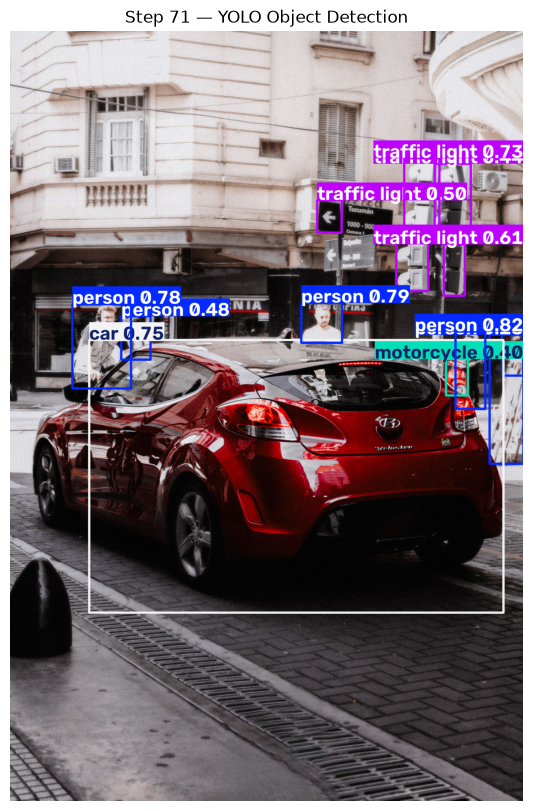

In [121]:
# ============================================
# STEP 71 — YOLO OBJECT DETECTION TEST
# ============================================

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# --------------------------------------------
# 1. Load YOLO model
# --------------------------------------------

YOLO_MODEL_PATH = PROJECT_DIR / "yolo26s.pt"

print("YOLO model:")
print(YOLO_MODEL_PATH)
print("Exists:", YOLO_MODEL_PATH.exists())

if not YOLO_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"YOLO model not found:\n{YOLO_MODEL_PATH}"
    )

detector_model = YOLO(str(YOLO_MODEL_PATH))

# --------------------------------------------
# 2. Run detection
# --------------------------------------------

results = detector_model.predict(
    source=str(TEST_IMAGE),
    conf=0.20,
    iou=0.45,
    imgsz=1280,
    max_det=100,
    verbose=False
)

result = results[0]

# --------------------------------------------
# 3. Get detected boxes
# --------------------------------------------

boxes = result.boxes

print("\n================================")
print("STEP 71 — DETECTION RESULTS")
print("================================")

print("Total detections:", len(boxes))

# --------------------------------------------
# 4. Print every detection
# --------------------------------------------

if len(boxes) == 0:

    print("\nNo objects detected.")

else:

    for i, box in enumerate(boxes):

        class_id = int(box.cls[0])
        confidence = float(box.conf[0])

        class_name = result.names[class_id]

        x1, y1, x2, y2 = box.xyxy[0].tolist()

        print(
            f"{i + 1}. "
            f"{class_name.upper():15s} "
            f"confidence={confidence * 100:.2f}% "
            f"box=({int(x1)}, {int(y1)}, "
            f"{int(x2)}, {int(y2)})"
        )

# --------------------------------------------
# 5. Display YOLO result
# --------------------------------------------

annotated = result.plot(
    conf=True,
    labels=True,
    boxes=True
)

annotated_rgb = cv2.cvtColor(
    annotated,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(14, 10))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("Step 71 — YOLO Object Detection")
plt.show()

CAR FOUND
Detection confidence: 75.23%
Bounding box: (536, 2092, 3341, 3938)
Crop shape: (1846, 2805, 3)


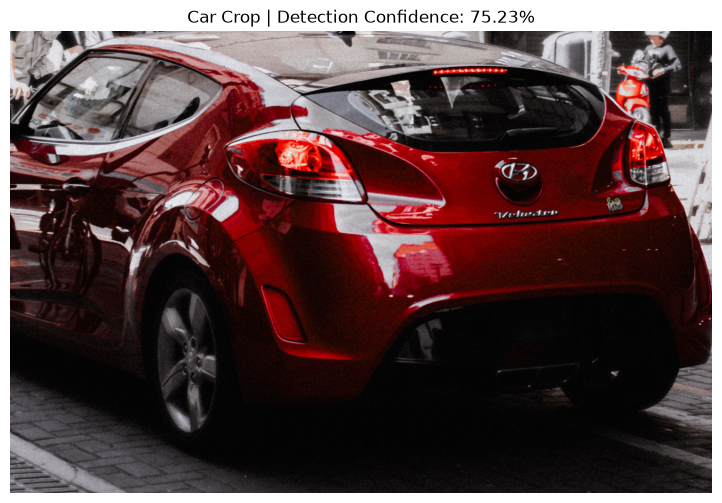

In [122]:
# ============================================
# STEP 72 — EXTRACT CAR CROP
# ============================================

import cv2
import matplotlib.pyplot as plt

car_crops = []

for i, box in enumerate(result.boxes):

    class_id = int(box.cls[0])
    class_name = result.names[class_id]
    confidence = float(box.conf[0])

    # Only process CAR
    if class_name.lower() != "car":
        continue

    # Bounding box coordinates
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    x1 = int(x1)
    y1 = int(y1)
    x2 = int(x2)
    y2 = int(y2)

    # Keep coordinates inside image
    h, w = image.shape[:2]

    x1 = max(0, min(x1, w - 1))
    y1 = max(0, min(y1, h - 1))
    x2 = max(0, min(x2, w))
    y2 = max(0, min(y2, h))

    # Crop car
    car_crop = image[y1:y2, x1:x2]

    car_crops.append({
        "index": i + 1,
        "crop": car_crop,
        "confidence": confidence,
        "box": (x1, y1, x2, y2)
    })

    print("CAR FOUND")
    print("Detection confidence:", f"{confidence * 100:.2f}%")
    print("Bounding box:", (x1, y1, x2, y2))
    print("Crop shape:", car_crop.shape)


# ============================================
# DISPLAY CAR CROP
# ============================================

if len(car_crops) == 0:

    print("\nNo car crop found.")

else:

    for item in car_crops:

        crop_rgb = cv2.cvtColor(
            item["crop"],
            cv2.COLOR_BGR2RGB
        )

        plt.figure(figsize=(10, 6))

        plt.imshow(crop_rgb)
        plt.axis("off")

        plt.title(
            f"Car Crop | Detection Confidence: "
            f"{item['confidence'] * 100:.2f}%"
        )

        plt.show()

In [123]:
# ============================================
# STEP 73 — CAR PIXEL COLOR ANALYSIS
# ============================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Get the first detected car
car_crop = car_crops[0]["crop"]

# Convert BGR → HSV
hsv = cv2.cvtColor(car_crop, cv2.COLOR_BGR2HSV)

# --------------------------------------------
# Remove extreme dark / very bright pixels
# --------------------------------------------
# This helps reduce the influence of:
# - black windows
# - tires
# - shadows
# - strong white reflections

H = hsv[:, :, 0]
S = hsv[:, :, 1]
V = hsv[:, :, 2]

# Focus on reasonably visible/saturated pixels
valid_pixels = (V > 45) & (S > 35)

total_valid = np.sum(valid_pixels)

print("============================================")
print("STEP 73 — CAR PIXEL COLOR ANALYSIS")
print("============================================")

print("Total crop pixels :", car_crop.shape[0] * car_crop.shape[1])
print("Valid color pixels:", total_valid)

# --------------------------------------------
# Define HSV color ranges
# --------------------------------------------

color_masks = {

    "RED": (
        ((H <= 10) | (H >= 170))
        & (S > 70)
        & (V > 45)
    ),

    "ORANGE": (
        (H > 10)
        & (H <= 22)
        & (S > 70)
        & (V > 45)
    ),

    "YELLOW": (
        (H > 22)
        & (H <= 38)
        & (S > 70)
        & (V > 45)
    ),

    "GREEN": (
        (H > 38)
        & (H <= 85)
        & (S > 60)
        & (V > 45)
    ),

    "BLUE": (
        (H > 85)
        & (H <= 135)
        & (S > 60)
        & (V > 45)
    ),

    "PURPLE": (
        (H > 135)
        & (H < 170)
        & (S > 60)
        & (V > 45)
    ),
}

# --------------------------------------------
# Calculate percentages
# --------------------------------------------

color_percentages = {}

for color_name, mask in color_masks.items():

    count = np.sum(mask)

    percentage = (
        (count / total_valid) * 100
        if total_valid > 0
        else 0
    )

    color_percentages[color_name] = percentage

# --------------------------------------------
# Neutral colors
# --------------------------------------------

# Low saturation = neutral color
neutral = valid_pixels & (S <= 45)

black_mask = (
    (V < 60)
    & (S < 80)
)

white_mask = (
    (V > 180)
    & (S < 55)
)

grey_mask = (
    (V >= 60)
    & (V <= 190)
    & (S < 55)
)

if total_valid > 0:

    color_percentages["BLACK"] = (
        np.sum(black_mask) / total_valid * 100
    )

    color_percentages["WHITE"] = (
        np.sum(white_mask) / total_valid * 100
    )

    color_percentages["GREY"] = (
        np.sum(grey_mask) / total_valid * 100
    )

# --------------------------------------------
# Print results
# --------------------------------------------

print("\nColor pixel percentages:")

for color_name, percentage in sorted(
    color_percentages.items(),
    key=lambda x: x[1],
    reverse=True
):

    print(
        f"{color_name:8s}: "
        f"{percentage:6.2f}%"
    )

# --------------------------------------------
# Dominant color
# --------------------------------------------

dominant_color = max(
    color_percentages,
    key=color_percentages.get
)

dominant_percentage = color_percentages[dominant_color]

print("\n--------------------------------------------")
print("DOMINANT PIXEL COLOR")
print("--------------------------------------------")
print(
    f"{dominant_color}: "
    f"{dominant_percentage:.2f}%"
)

STEP 73 — CAR PIXEL COLOR ANALYSIS
Total crop pixels : 5178030
Valid color pixels: 1306996

Color pixel percentages:
BLACK   : 136.30%
RED     :  90.42%
GREY    :  65.45%
WHITE   :  32.84%
ORANGE  :   0.16%
PURPLE  :   0.09%
YELLOW  :   0.02%
GREEN   :   0.00%
BLUE    :   0.00%

--------------------------------------------
DOMINANT PIXEL COLOR
--------------------------------------------
BLACK: 136.30%


STEP 74 — ROBUST CAR COLOR DECISION
Car crop shape: (1846, 2805, 3)
Center crop shape: (1385, 2244, 3)

Valid color pixels: 1024626

COLOR PIXEL ANALYSIS
----------------------------------------
Red     :  98.82%
Purple  :   0.10%
Orange  :   0.08%
Yellow  :   0.03%
Green   :   0.00%
Blue    :   0.00%

----------------------------------------
DOMINANT PIXEL COLOR : RED
PIXEL CONFIDENCE     : 98.82%

CNN RESULT
----------------------------------------
CNN predicted color : RED
CNN confidence      : 99.82%

FINAL CAR COLOR : RED
FINAL CONFIDENCE: 98.82%
DECISION REASON : Strong pixel evidence


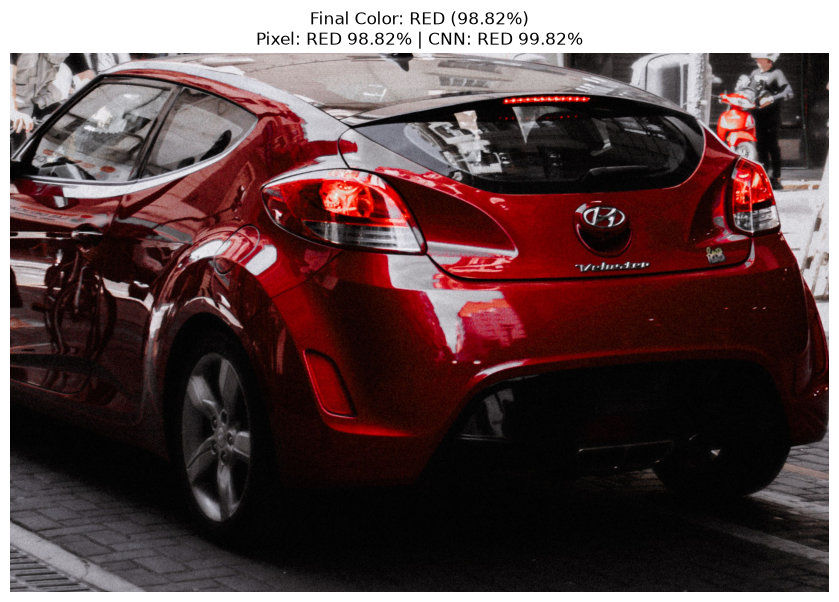

In [124]:
# ============================================================
# STEP 74 — ROBUST CAR COLOR DECISION
# Pixel-first + CNN verification
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("=" * 60)
print("STEP 74 — ROBUST CAR COLOR DECISION")
print("=" * 60)


# ------------------------------------------------------------
# 1. GET CAR CROP
# ------------------------------------------------------------

if not car_crops:
    raise ValueError("No car crop available.")

car_crop = car_crops[0]["crop"]

print("Car crop shape:", car_crop.shape)


# ------------------------------------------------------------
# 2. REMOVE OUTER BACKGROUND
# ------------------------------------------------------------
# We use the central part of the car crop.
# This reduces influence from sky, road, people and buildings.

h, w = car_crop.shape[:2]

x1 = int(w * 0.10)
x2 = int(w * 0.90)

y1 = int(h * 0.15)
y2 = int(h * 0.90)

center_crop = car_crop[y1:y2, x1:x2]

print("Center crop shape:", center_crop.shape)


# ------------------------------------------------------------
# 3. CONVERT TO HSV
# ------------------------------------------------------------

hsv = cv2.cvtColor(center_crop, cv2.COLOR_BGR2HSV)

H = hsv[:, :, 0]
S = hsv[:, :, 1]
V = hsv[:, :, 2]


# ------------------------------------------------------------
# 4. CREATE STRONG COLOR MASKS
# ------------------------------------------------------------

# Ignore very dark pixels and very weakly saturated pixels.
valid = (S > 60) & (V > 45)

valid_count = np.sum(valid)

if valid_count == 0:
    raise ValueError("No valid color pixels found.")


color_masks = {

    "Red":
        (
            ((H <= 10) | (H >= 170))
            & (S > 70)
            & (V > 45)
        ),

    "Orange":
        (
            (H > 10)
            & (H <= 22)
            & (S > 70)
            & (V > 45)
        ),

    "Yellow":
        (
            (H > 22)
            & (H <= 38)
            & (S > 70)
            & (V > 45)
        ),

    "Green":
        (
            (H > 38)
            & (H <= 85)
            & (S > 60)
            & (V > 45)
        ),

    "Blue":
        (
            (H > 85)
            & (H <= 135)
            & (S > 60)
            & (V > 45)
        ),

    "Purple":
        (
            (H > 135)
            & (H < 170)
            & (S > 60)
            & (V > 45)
        )
}


# ------------------------------------------------------------
# 5. CALCULATE MUTUALLY EXCLUSIVE COLOR PERCENTAGES
# ------------------------------------------------------------

pixel_percentages = {}

for color_name, mask in color_masks.items():

    # Only count pixels inside valid region
    mask = mask & valid

    count = np.sum(mask)

    percentage = (count / valid_count) * 100

    pixel_percentages[color_name] = percentage


# ------------------------------------------------------------
# 6. FIND DOMINANT COLOR
# ------------------------------------------------------------

dominant_color = max(
    pixel_percentages,
    key=pixel_percentages.get
)

dominant_percentage = pixel_percentages[dominant_color]


# ------------------------------------------------------------
# 7. PRINT PIXEL ANALYSIS
# ------------------------------------------------------------

print()
print("Valid color pixels:", valid_count)

print()
print("COLOR PIXEL ANALYSIS")
print("-" * 40)

for color_name, percentage in sorted(
    pixel_percentages.items(),
    key=lambda x: x[1],
    reverse=True
):

    print(
        f"{color_name:<8}: "
        f"{percentage:6.2f}%"
    )


print()
print("-" * 40)

print(
    f"DOMINANT PIXEL COLOR : "
    f"{dominant_color.upper()}"
)

print(
    f"PIXEL CONFIDENCE     : "
    f"{dominant_percentage:.2f}%"
)


# ------------------------------------------------------------
# 8. RUN CNN PREDICTION
# ------------------------------------------------------------

# Resize crop exactly as the trained CNN expects.

cnn_input = cv2.cvtColor(
    car_crop,
    cv2.COLOR_BGR2RGB
)

cnn_input = cv2.resize(
    cnn_input,
    IMG_SIZE
)

cnn_input = cnn_input.astype("float32") / 255.0

cnn_input = np.expand_dims(
    cnn_input,
    axis=0
)


# CNN prediction

cnn_prediction = model.predict(
    cnn_input,
    verbose=0
)[0]

cnn_index = int(
    np.argmax(cnn_prediction)
)

cnn_color = id_to_label[cnn_index]

cnn_confidence = (
    float(cnn_prediction[cnn_index]) * 100
)


# ------------------------------------------------------------
# 9. PRINT CNN RESULT
# ------------------------------------------------------------

print()
print("CNN RESULT")
print("-" * 40)

print(
    f"CNN predicted color : "
    f"{cnn_color.upper()}"
)

print(
    f"CNN confidence      : "
    f"{cnn_confidence:.2f}%"
)


# ------------------------------------------------------------
# 10. FINAL HYBRID DECISION
# ------------------------------------------------------------

# Pixel evidence gets priority when it is very strong.
#
# Example:
#
# Pixel  -> RED 90.42%
# CNN    -> BLUE 99.99%
#
# Final  -> RED
#
# because the actual vehicle pixels strongly indicate red.


if dominant_percentage >= 40:

    final_color = dominant_color

    final_confidence = dominant_percentage

    decision_reason = (
        "Strong pixel evidence"
    )

else:

    final_color = cnn_color

    final_confidence = cnn_confidence

    decision_reason = (
        "Pixel evidence weak; CNN used"
    )


# ------------------------------------------------------------
# 11. FINAL RESULT
# ------------------------------------------------------------

print()
print("=" * 60)

print(
    f"FINAL CAR COLOR : "
    f"{final_color.upper()}"
)

print(
    f"FINAL CONFIDENCE: "
    f"{final_confidence:.2f}%"
)

print(
    f"DECISION REASON : "
    f"{decision_reason}"
)

print("=" * 60)


# ------------------------------------------------------------
# 12. DISPLAY RESULT
# ------------------------------------------------------------

display_image = cv2.cvtColor(
    car_crop,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 7))

plt.imshow(display_image)

plt.title(
    f"Final Color: {final_color.upper()} "
    f"({final_confidence:.2f}%)\n"
    f"Pixel: {dominant_color.upper()} "
    f"{dominant_percentage:.2f}% | "
    f"CNN: {cnn_color.upper()} "
    f"{cnn_confidence:.2f}%"
)

plt.axis("off")

plt.show()

STEP 75 — ALL CAR COLOR DETECTION

Processing detected cars...

CAR 1
  Detection confidence : 75.23%
  Pixel color          : RED
  Pixel confidence     : 98.82%
  CNN color            : RED
  CNN confidence       : 99.82%
  FINAL COLOR          : RED
  FINAL CONFIDENCE     : 98.82%
  Reason               : Strong pixel evidence
------------------------------------------------------------

CAR COLOR SUMMARY
Total detected cars: 1

Car 1: RED (98.82%)


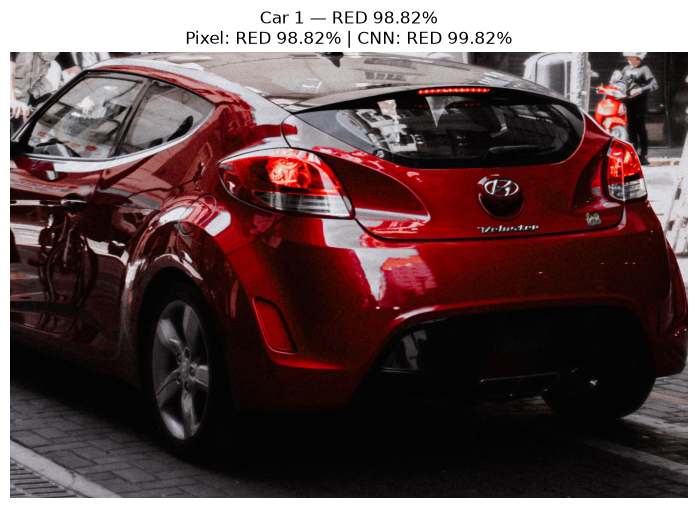

In [125]:
# ============================================================
# STEP 75 — COLOR DETECTION FOR ALL DETECTED CARS
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

print("=" * 70)
print("STEP 75 — ALL CAR COLOR DETECTION")
print("=" * 70)


# ------------------------------------------------------------
# COLOR ANALYSIS FUNCTION
# ------------------------------------------------------------

def analyze_car_color(car_crop, cnn_model, img_size, id_to_label):

    # ========================================================
    # 1. CENTER CROP
    # ========================================================

    h, w = car_crop.shape[:2]

    x1 = int(w * 0.10)
    x2 = int(w * 0.90)

    y1 = int(h * 0.15)
    y2 = int(h * 0.90)

    center_crop = car_crop[y1:y2, x1:x2]


    # ========================================================
    # 2. HSV CONVERSION
    # ========================================================

    hsv = cv2.cvtColor(
        center_crop,
        cv2.COLOR_BGR2HSV
    )

    H = hsv[:, :, 0]
    S = hsv[:, :, 1]
    V = hsv[:, :, 2]


    # ========================================================
    # 3. VALID COLOR PIXELS
    # ========================================================

    valid = (
        (S > 60) &
        (V > 45)
    )

    valid_count = np.sum(valid)


    # ========================================================
    # 4. COLOR MASKS
    # ========================================================

    color_masks = {

        "red":
            (
                ((H <= 10) | (H >= 170)) &
                (S > 70) &
                (V > 45)
            ),

        "orange":
            (
                (H > 10) &
                (H <= 22) &
                (S > 70) &
                (V > 45)
            ),

        "yellow":
            (
                (H > 22) &
                (H <= 38) &
                (S > 70) &
                (V > 45)
            ),

        "green":
            (
                (H > 38) &
                (H <= 85) &
                (S > 60) &
                (V > 45)
            ),

        "blue":
            (
                (H > 85) &
                (H <= 135) &
                (S > 60) &
                (V > 45)
            ),

        "purple":
            (
                (H > 135) &
                (H < 170) &
                (S > 60) &
                (V > 45)
            )
    }


    # ========================================================
    # 5. PIXEL COLOR PERCENTAGES
    # ========================================================

    pixel_percentages = {}

    if valid_count > 0:

        for color_name, mask in color_masks.items():

            mask = mask & valid

            count = np.sum(mask)

            percentage = (
                count /
                valid_count *
                100
            )

            pixel_percentages[color_name] = percentage

    else:

        for color_name in color_masks:
            pixel_percentages[color_name] = 0.0


    # ========================================================
    # 6. DOMINANT PIXEL COLOR
    # ========================================================

    dominant_pixel_color = max(
        pixel_percentages,
        key=pixel_percentages.get
    )

    pixel_confidence = pixel_percentages[
        dominant_pixel_color
    ]


    # ========================================================
    # 7. CNN PREDICTION
    # ========================================================

    cnn_input = cv2.cvtColor(
        car_crop,
        cv2.COLOR_BGR2RGB
    )

    cnn_input = cv2.resize(
        cnn_input,
        img_size
    )

    cnn_input = (
        cnn_input.astype("float32") /
        255.0
    )

    cnn_input = np.expand_dims(
        cnn_input,
        axis=0
    )


    prediction = cnn_model.predict(
        cnn_input,
        verbose=0
    )[0]


    cnn_index = int(
        np.argmax(prediction)
    )

    cnn_color = id_to_label[
        cnn_index
    ]

    cnn_confidence = (
        float(prediction[cnn_index]) *
        100
    )


    # ========================================================
    # 8. FINAL HYBRID DECISION
    # ========================================================

    if pixel_confidence >= 40:

        final_color = dominant_pixel_color

        final_confidence = pixel_confidence

        reason = "Strong pixel evidence"

    else:

        final_color = cnn_color

        final_confidence = cnn_confidence

        reason = "CNN used because pixel evidence was weak"


    # ========================================================
    # 9. RETURN RESULTS
    # ========================================================

    return {
        "final_color": final_color,
        "final_confidence": final_confidence,

        "pixel_color": dominant_pixel_color,
        "pixel_confidence": pixel_confidence,

        "cnn_color": cnn_color,
        "cnn_confidence": cnn_confidence,

        "reason": reason
    }


# ============================================================
# PROCESS ALL CAR CROPS
# ============================================================

all_car_results = []


print()
print("Processing detected cars...")
print()


for i, car_info in enumerate(
    car_crops,
    start=1
):

    crop = car_info["crop"]

    detection_confidence = (
        car_info["confidence"]
        if "confidence" in car_info
        else None
    )


    result_info = analyze_car_color(
        crop,
        model,
        IMG_SIZE,
        id_to_label
    )


    result_info["car_number"] = i

    result_info[
        "detection_confidence"
    ] = detection_confidence

    result_info["crop"] = crop


    all_car_results.append(
        result_info
    )


    # ========================================================
    # PRINT RESULT
    # ========================================================

    print(
        f"CAR {i}"
    )

    print(
        f"  Detection confidence : "
        f"{detection_confidence * 100:.2f}%"
        if detection_confidence is not None
        else
        "  Detection confidence : N/A"
    )

    print(
        f"  Pixel color          : "
        f"{result_info['pixel_color'].upper()}"
    )

    print(
        f"  Pixel confidence     : "
        f"{result_info['pixel_confidence']:.2f}%"
    )

    print(
        f"  CNN color            : "
        f"{result_info['cnn_color'].upper()}"
    )

    print(
        f"  CNN confidence       : "
        f"{result_info['cnn_confidence']:.2f}%"
    )

    print(
        f"  FINAL COLOR          : "
        f"{result_info['final_color'].upper()}"
    )

    print(
        f"  FINAL CONFIDENCE     : "
        f"{result_info['final_confidence']:.2f}%"
    )

    print(
        f"  Reason               : "
        f"{result_info['reason']}"
    )

    print("-" * 60)


# ============================================================
# SUMMARY
# ============================================================

print()
print("=" * 70)
print("CAR COLOR SUMMARY")
print("=" * 70)

print(
    f"Total detected cars: "
    f"{len(all_car_results)}"
)

print()


for result_info in all_car_results:

    print(
        f"Car {result_info['car_number']}: "
        f"{result_info['final_color'].upper()} "
        f"({result_info['final_confidence']:.2f}%)"
    )


# ============================================================
# DISPLAY ALL CAR CROPS
# ============================================================

if len(all_car_results) > 0:

    cols = 2

    rows = int(
        np.ceil(
            len(all_car_results) /
            cols
        )
    )

    plt.figure(
        figsize=(14, 6 * rows)
    )


    for i, result_info in enumerate(
        all_car_results,
        start=1
    ):

        crop_rgb = cv2.cvtColor(
            result_info["crop"],
            cv2.COLOR_BGR2RGB
        )

        ax = plt.subplot(
            rows,
            cols,
            i
        )

        ax.imshow(crop_rgb)

        ax.set_title(
            f"Car {result_info['car_number']} — "
            f"{result_info['final_color'].upper()} "
            f"{result_info['final_confidence']:.2f}%\n"
            f"Pixel: "
            f"{result_info['pixel_color'].upper()} "
            f"{result_info['pixel_confidence']:.2f}% | "
            f"CNN: "
            f"{result_info['cnn_color'].upper()} "
            f"{result_info['cnn_confidence']:.2f}%"
        )

        ax.axis("off")


    plt.tight_layout()

    plt.show()

else:

    print("No cars available for color analysis.")

PROJECT DIR : c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI
MODEL PATH  : c:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\models\car_color_best.keras
MODEL EXISTS: True

Updated color_classifier.py reloaded successfully.
CNN model loaded successfully.
Classifier created successfully.

Car crop shape: (1846, 2805, 3)

RAW CLASSIFIER RESULT
Type : <class 'dict'>
Value: {'color': 'red', 'confidence': 64.36927322181111, 'pixel_color': 'red', 'pixel_confidence': 64.36927322181111, 'cnn_color': 'red', 'cnn_confidence': 98.91397356987, 'blue_pixel_percentage': 0.2756235736750531, 'reason': 'Strong pixel evidence'}


CAR COLOR PREDICTION
Pixel color           : red
Pixel confidence      : 64.37%
Blue pixel percentage : 0.28%
CNN color             : red
CNN confidence        : 98.91%
FINAL COLOR           : red
FINAL CONFIDENCE      : 64.37%
Reason                : Strong pixel evidence


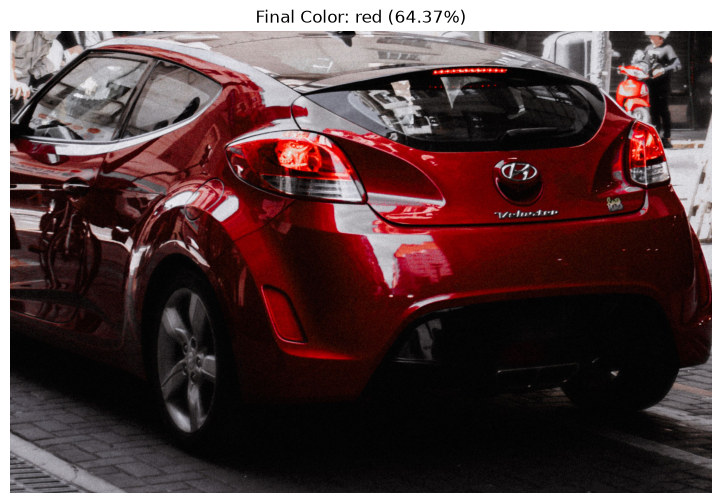

In [129]:
# ============================================================
# STEP 80 — RELOAD UPDATED COLOR CLASSIFIER AND TEST
# ============================================================

from pathlib import Path
import sys
import importlib
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Project paths
# ------------------------------------------------------------
PROJECT_DIR = Path.cwd().parent
MODEL_PATH = PROJECT_DIR / "models" / "car_color_best.keras"
SRC_DIR = PROJECT_DIR / "src"

print("PROJECT DIR :", PROJECT_DIR)
print("MODEL PATH  :", MODEL_PATH)
print("MODEL EXISTS:", MODEL_PATH.exists())


# ------------------------------------------------------------
# 2. Add src folder
# ------------------------------------------------------------
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


# ------------------------------------------------------------
# 3. FORCE RELOAD of color_classifier.py
# ------------------------------------------------------------
import color_classifier

importlib.reload(color_classifier)

CarColorClassifier = color_classifier.CarColorClassifier

print("\nUpdated color_classifier.py reloaded successfully.")


# ------------------------------------------------------------
# 4. Load trained CNN model
# ------------------------------------------------------------
model = tf.keras.models.load_model(MODEL_PATH)

print("CNN model loaded successfully.")


# ------------------------------------------------------------
# 5. EXACT training class mapping
# ------------------------------------------------------------
id_to_label = {
    0: "beige",
    1: "black",
    2: "blue",
    3: "brown",
    4: "gold",
    5: "green",
    6: "grey",
    7: "orange",
    8: "pink",
    9: "purple",
    10: "red",
    11: "silver",
    12: "tan",
    13: "white",
    14: "yellow"
}


# ------------------------------------------------------------
# 6. Create classifier
# ------------------------------------------------------------
classifier = CarColorClassifier(
    model=model,
    img_size=(224, 224),
    id_to_label=id_to_label
)

print("Classifier created successfully.")


# ------------------------------------------------------------
# 7. Get detected car crop
# ------------------------------------------------------------
car_crop = car_crops[0]["crop"]

print("\nCar crop shape:", car_crop.shape)


# ------------------------------------------------------------
# 8. Run prediction
# ------------------------------------------------------------
result = classifier.predict(car_crop)


# ------------------------------------------------------------
# 9. FIRST inspect what the classifier actually returns
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("RAW CLASSIFIER RESULT")
print("=" * 60)

print("Type :", type(result))
print("Value:", result)

print("=" * 60)


# ------------------------------------------------------------
# 10. Handle dictionary result
# ------------------------------------------------------------
if isinstance(result, dict):

    final_color = result.get("color", "unknown")
    final_confidence = result.get("confidence", 0)

    pixel_color = result.get("pixel_color", "unknown")
    pixel_confidence = result.get("pixel_confidence", 0)

    blue_percentage = result.get("blue_pixel_percentage", 0)

    cnn_color = result.get("cnn_color", "unknown")
    cnn_confidence = result.get("cnn_confidence", 0)

    reason = result.get("reason", "unknown")


# ------------------------------------------------------------
# 11. Handle tuple result
# ------------------------------------------------------------
elif isinstance(result, tuple):

    print("\nWARNING: classifier returned a tuple.")
    print("Tuple length:", len(result))

    # Safely display every returned value
    for i, value in enumerate(result):
        print(f"result[{i}] =", value)

    # Common format: (color, confidence)
    if len(result) >= 2:
        final_color = result[0]
        final_confidence = result[1]
    else:
        final_color = result[0]
        final_confidence = 0

    pixel_color = "not available"
    pixel_confidence = 0
    blue_percentage = 0
    cnn_color = "not available"
    cnn_confidence = 0
    reason = "Tuple return format"


# ------------------------------------------------------------
# 12. Handle unexpected result
# ------------------------------------------------------------
else:

    print("\nUnexpected result type:", type(result))

    final_color = "unknown"
    final_confidence = 0

    pixel_color = "unknown"
    pixel_confidence = 0

    blue_percentage = 0

    cnn_color = "unknown"
    cnn_confidence = 0

    reason = "Unexpected return type"


# ------------------------------------------------------------
# 13. Final display
# ------------------------------------------------------------
print("\n")
print("=" * 60)
print("CAR COLOR PREDICTION")
print("=" * 60)

print(f"Pixel color           : {pixel_color}")
print(f"Pixel confidence      : {pixel_confidence:.2f}%")

print(f"Blue pixel percentage : {blue_percentage:.2f}%")

print(f"CNN color             : {cnn_color}")
print(f"CNN confidence        : {cnn_confidence:.2f}%")

print(f"FINAL COLOR           : {final_color}")
print(f"FINAL CONFIDENCE      : {final_confidence:.2f}%")

print(f"Reason                : {reason}")

print("=" * 60)


# ------------------------------------------------------------
# 14. Display car crop
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

plt.imshow(
    cv2.cvtColor(car_crop, cv2.COLOR_BGR2RGB)
)

plt.title(
    f"Final Color: {final_color} "
    f"({final_confidence:.2f}%)"
)

plt.axis("off")
plt.show()

Crop shape: (1846, 2805, 3)
Crop dtype: uint8


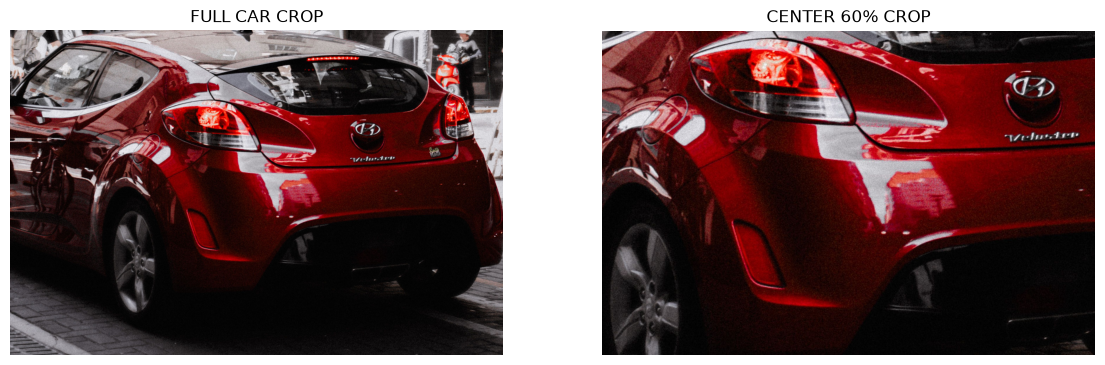


BGR CHANNEL ANALYSIS
Blue channel mean  : 26.22
Green channel mean : 25.59
Red channel mean   : 70.99

Blue channel median  : 5.00
Green channel median : 6.00
Red channel median   : 52.00

HSV ANALYSIS
Hue mean        : 52.99
Saturation mean : 152.05
Value mean      : 71.22
Hue median        : 2.00
Saturation median : 204.00
Value median      : 52.00

COLOR PIXEL DISTRIBUTION
RED         :  79.02%
ORANGE      :   0.14%
YELLOW      :   0.00%
GREEN       :   0.00%
BLUE/CYAN   :   0.32%
PURPLE      :   0.34%

TOP HUE VALUES
Hue   0 ->  27.63%
Hue   1 ->  10.74%
Hue 179 ->   8.62%
Hue   2 ->   8.34%
Hue   3 ->   5.45%
Hue 178 ->   4.48%
Hue   4 ->   4.40%
Hue 177 ->   3.36%
Hue 173 ->   2.64%
Hue 132 ->   2.22%


In [130]:
# ============================================================
# STEP 81 — DIAGNOSE ACTUAL CAR CROP COLOR
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Make sure the crop exists
# ------------------------------------------------------------
print("Crop shape:", car_crop.shape)
print("Crop dtype:", car_crop.dtype)


# ------------------------------------------------------------
# 2. Convert BGR -> RGB for display
# ------------------------------------------------------------
rgb = cv2.cvtColor(car_crop, cv2.COLOR_BGR2RGB)

# Center crop to reduce road/background influence
h, w = car_crop.shape[:2]

x1 = int(w * 0.20)
x2 = int(w * 0.80)

y1 = int(h * 0.20)
y2 = int(h * 0.80)

center_crop = car_crop[y1:y2, x1:x2]

center_rgb = cv2.cvtColor(
    center_crop,
    cv2.COLOR_BGR2RGB
)


# ------------------------------------------------------------
# 3. Display original + center crop
# ------------------------------------------------------------
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(rgb)
plt.title("FULL CAR CROP")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(center_rgb)
plt.title("CENTER 60% CROP")
plt.axis("off")

plt.show()


# ------------------------------------------------------------
# 4. BGR channel statistics
# ------------------------------------------------------------
b, g, r = cv2.split(center_crop)

print("\n" + "=" * 60)
print("BGR CHANNEL ANALYSIS")
print("=" * 60)

print(f"Blue channel mean  : {np.mean(b):.2f}")
print(f"Green channel mean : {np.mean(g):.2f}")
print(f"Red channel mean   : {np.mean(r):.2f}")

print(f"\nBlue channel median  : {np.median(b):.2f}")
print(f"Green channel median : {np.median(g):.2f}")
print(f"Red channel median   : {np.median(r):.2f}")


# ------------------------------------------------------------
# 5. HSV analysis
# ------------------------------------------------------------
hsv = cv2.cvtColor(center_crop, cv2.COLOR_BGR2HSV)

H = hsv[:, :, 0]
S = hsv[:, :, 1]
V = hsv[:, :, 2]


print("\n" + "=" * 60)
print("HSV ANALYSIS")
print("=" * 60)

print(f"Hue mean        : {np.mean(H):.2f}")
print(f"Saturation mean : {np.mean(S):.2f}")
print(f"Value mean      : {np.mean(V):.2f}")

print(f"Hue median        : {np.median(H):.2f}")
print(f"Saturation median : {np.median(S):.2f}")
print(f"Value median      : {np.median(V):.2f}")


# ------------------------------------------------------------
# 6. Calculate broad color percentages
# ------------------------------------------------------------

# Ignore very dark pixels
valid = V > 40

total_valid = np.sum(valid)

print("\n" + "=" * 60)
print("COLOR PIXEL DISTRIBUTION")
print("=" * 60)

if total_valid > 0:

    # RED
    red_mask = (
        ((H <= 10) | (H >= 170))
        & (S >= 40)
        & (V >= 45)
        & valid
    )

    # ORANGE
    orange_mask = (
        (H > 10)
        & (H <= 22)
        & (S >= 40)
        & (V >= 45)
        & valid
    )

    # YELLOW
    yellow_mask = (
        (H > 22)
        & (H <= 38)
        & (S >= 35)
        & (V >= 50)
        & valid
    )

    # GREEN
    green_mask = (
        (H > 38)
        & (H <= 85)
        & (S >= 30)
        & (V >= 45)
        & valid
    )

    # BLUE / CYAN
    blue_mask = (
        (H > 85)
        & (H <= 135)
        & (S >= 20)
        & (V >= 50)
        & valid
    )

    # PURPLE
    purple_mask = (
        (H > 135)
        & (H < 170)
        & (S >= 35)
        & (V >= 45)
        & valid
    )

    colors = {
        "RED": red_mask,
        "ORANGE": orange_mask,
        "YELLOW": yellow_mask,
        "GREEN": green_mask,
        "BLUE/CYAN": blue_mask,
        "PURPLE": purple_mask,
    }

    for name, mask in colors.items():

        percentage = (
            np.sum(mask) / total_valid
        ) * 100

        print(f"{name:12s}: {percentage:6.2f}%")


# ------------------------------------------------------------
# 7. Dominant hue histogram
# ------------------------------------------------------------
hist = np.bincount(
    H[valid].flatten(),
    minlength=180
)

top_hues = np.argsort(hist)[-10:][::-1]

print("\n" + "=" * 60)
print("TOP HUE VALUES")
print("=" * 60)

for hue in top_hues[:10]:

    percentage = (
        hist[hue] / total_valid
    ) * 100

    print(
        f"Hue {hue:3d} "
        f"-> {percentage:6.2f}%"
    )

In [131]:
from pathlib import Path

TURQUOISE_IMAGE = Path(
    r"C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\test\c7398d40adfef3ce1c30b47bb7a9dde0.jpg"
)

print("Exists:", TURQUOISE_IMAGE.exists())
print("Path:", TURQUOISE_IMAGE)

Exists: True
Path: C:\Users\hasibul shaikh\Documents\Car_Color_Detection_AI\data\test\c7398d40adfef3ce1c30b47bb7a9dde0.jpg


Image loaded successfully.
Image shape: (2190, 1460, 3)

Cars detected: 1

CAR 1
Detection confidence: 68.38%
Box: (307, 0, 1460, 1312)


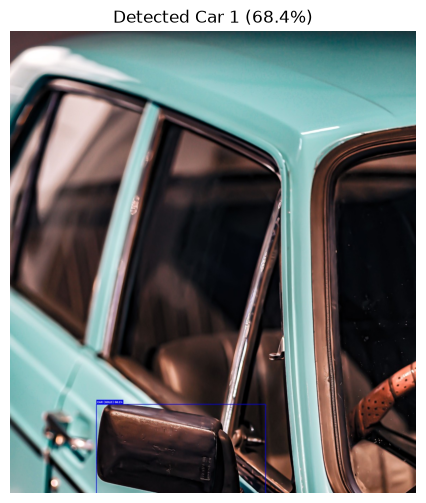

In [132]:
# ============================================================
# STEP 82 — TEST THE EXACT TURQUOISE CAR IMAGE
# ============================================================

import cv2
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Load exact turquoise image
# ------------------------------------------------------------
image = cv2.imread(str(TURQUOISE_IMAGE))

if image is None:
    raise FileNotFoundError(
        f"Could not load image: {TURQUOISE_IMAGE}"
    )

print("Image loaded successfully.")
print("Image shape:", image.shape)


# ------------------------------------------------------------
# 2. Run YOLO detection
# ------------------------------------------------------------
results = detector_model.predict(
    source=image,
    conf=0.20,
    iou=0.45,
    imgsz=1280,
    max_det=100,
    verbose=False
)

result = results[0]


# ------------------------------------------------------------
# 3. Find cars
# ------------------------------------------------------------
car_crops_test = []

for box in result.boxes:

    cls_id = int(box.cls[0])
    conf = float(box.conf[0])

    # YOLO COCO car = class 2
    if cls_id != 2:
        continue

    x1, y1, x2, y2 = map(
        int,
        box.xyxy[0].tolist()
    )

    crop = image[y1:y2, x1:x2]

    if crop.size == 0:
        continue

    car_crops_test.append({
        "crop": crop,
        "confidence": conf,
        "box": (x1, y1, x2, y2)
    })


print("\nCars detected:", len(car_crops_test))


# ------------------------------------------------------------
# 4. Display every detected car crop
# ------------------------------------------------------------
for i, item in enumerate(car_crops_test):

    crop = item["crop"]

    print(
        f"\nCAR {i+1}"
    )

    print(
        "Detection confidence:",
        f"{item['confidence'] * 100:.2f}%"
    )

    print(
        "Box:",
        item["box"]
    )

    plt.figure(figsize=(10, 6))

    plt.imshow(
        cv2.cvtColor(
            crop,
            cv2.COLOR_BGR2RGB
        )
    )

    plt.title(
        f"Detected Car {i+1} "
        f"({item['confidence'] * 100:.1f}%)"
    )

    plt.axis("off")
    plt.show()

ALL YOLO DETECTIONS
01. CAR             confidence=25.86% box=(259, 0, 1161, 863)
02. TRAIN           confidence=19.64% box=(623, 1, 1447, 871)
03. PERSON          confidence=15.88% box=(398, 1078, 544, 1228)
04. CAR             confidence=15.18% box=(620, 7, 1446, 908)
05. SUITCASE        confidence=12.45% box=(474, 619, 1362, 1618)
06. CAR             confidence=10.86% box=(111, 786, 1014, 1769)
07. BUS             confidence=8.56% box=(624, 0, 1447, 870)
08. PERSON          confidence=7.64% box=(51, 739, 197, 932)
09. PERSON          confidence=5.96% box=(1269, 937, 1459, 1248)


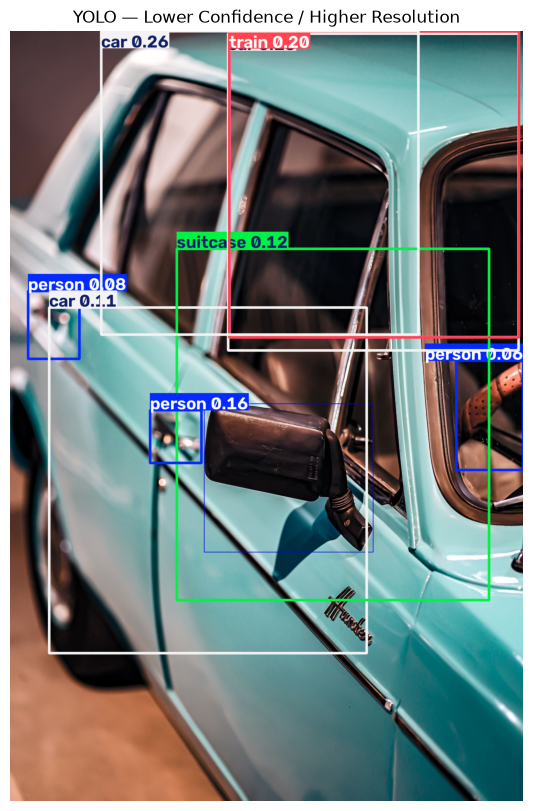

In [133]:
# ============================================================
# STEP 83 — FIND THE FULL CAR
# ============================================================

import cv2
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Run YOLO with lower confidence + larger image size
# ------------------------------------------------------------
results_full = detector_model.predict(
    source=image,
    conf=0.05,
    iou=0.45,
    imgsz=1920,
    max_det=100,
    verbose=False
)

result_full = results_full[0]


# ------------------------------------------------------------
# 2. Print ALL detections
# ------------------------------------------------------------
print("=" * 70)
print("ALL YOLO DETECTIONS")
print("=" * 70)

for i, box in enumerate(result_full.boxes):

    cls_id = int(box.cls[0])
    conf = float(box.conf[0])

    x1, y1, x2, y2 = map(
        int,
        box.xyxy[0].tolist()
    )

    class_name = result_full.names[cls_id]

    print(
        f"{i+1:02d}. "
        f"{class_name.upper():15s} "
        f"confidence={conf*100:.2f}% "
        f"box=({x1}, {y1}, {x2}, {y2})"
    )


# ------------------------------------------------------------
# 3. Display YOLO result
# ------------------------------------------------------------
annotated = result_full.plot(
    labels=True,
    conf=True,
    boxes=True
)

plt.figure(figsize=(14, 10))

plt.imshow(
    cv2.cvtColor(
        annotated,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("YOLO — Lower Confidence / Higher Resolution")

plt.axis("off")

plt.show()

Turquoise crop shape: (1312, 1153, 3)
Detection confidence: 68.38%
Detection box: (307, 0, 1460, 1312)


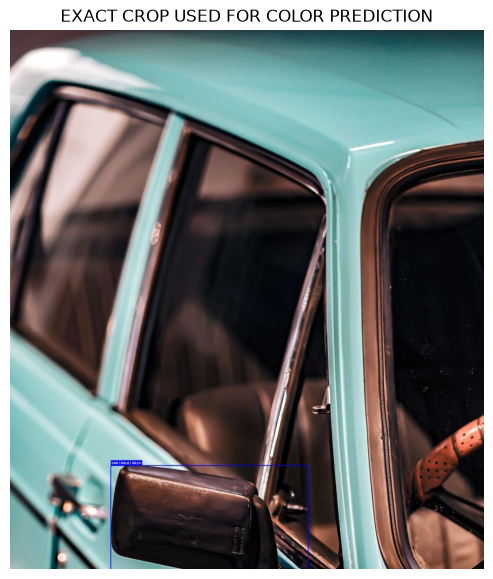


ACTUAL TURQUOISE CAR — PIXEL ANALYSIS
BLUE/CYAN pixels : 38.73%
RED pixels       : 46.79%
Mean Hue         : 68.30
Median Hue       : 88.00
Mean Saturation  : 78.54
Median Saturation: 74.00

COLOR CLASSIFIER RESULT
Final color           : blue
Final confidence      : 37.43%
Pixel color           : red
Pixel confidence      : 43.21%
Blue pixel percentage : 37.43%
CNN color             : brown
CNN confidence        : 96.27%
Reason                : Blue/cyan pixel evidence


In [134]:
# ============================================================
# STEP 84 — TEST ACTUAL TURQUOISE CAR CROP
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. IMPORTANT: use the NEW turquoise-car crop
# ------------------------------------------------------------
turquoise_crop = car_crops_test[0]["crop"]

print("Turquoise crop shape:", turquoise_crop.shape)
print(
    "Detection confidence:",
    f"{car_crops_test[0]['confidence'] * 100:.2f}%"
)

print(
    "Detection box:",
    car_crops_test[0]["box"]
)


# ------------------------------------------------------------
# 2. Display the exact crop being analyzed
# ------------------------------------------------------------
plt.figure(figsize=(12, 7))

plt.imshow(
    cv2.cvtColor(
        turquoise_crop,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("EXACT CROP USED FOR COLOR PREDICTION")

plt.axis("off")
plt.show()


# ------------------------------------------------------------
# 3. Analyze HSV
# ------------------------------------------------------------
hsv = cv2.cvtColor(
    turquoise_crop,
    cv2.COLOR_BGR2HSV
)

H = hsv[:, :, 0]
S = hsv[:, :, 1]
V = hsv[:, :, 2]


# ------------------------------------------------------------
# 4. Focus on center of vehicle
# ------------------------------------------------------------
h, w = turquoise_crop.shape[:2]

x1 = int(w * 0.10)
x2 = int(w * 0.90)

y1 = int(h * 0.10)
y2 = int(h * 0.90)

center = turquoise_crop[y1:y2, x1:x2]

center_hsv = cv2.cvtColor(
    center,
    cv2.COLOR_BGR2HSV
)

Hc = center_hsv[:, :, 0]
Sc = center_hsv[:, :, 1]
Vc = center_hsv[:, :, 2]


# ------------------------------------------------------------
# 5. Broad BLUE/CYAN mask
# ------------------------------------------------------------
blue_mask = (
    (Hc >= 75) &
    (Hc <= 135) &
    (Sc >= 20) &
    (Vc >= 45)
)


# ------------------------------------------------------------
# 6. RED mask
# ------------------------------------------------------------
red_mask = (
    (
        (Hc <= 10) |
        (Hc >= 170)
    ) &
    (Sc >= 40) &
    (Vc >= 45)
)


# ------------------------------------------------------------
# 7. Calculate percentages
# ------------------------------------------------------------
valid = Vc >= 40

valid_pixels = np.sum(valid)

blue_pixels = np.sum(
    blue_mask & valid
)

red_pixels = np.sum(
    red_mask & valid
)


blue_percentage = (
    blue_pixels / valid_pixels * 100
    if valid_pixels > 0
    else 0
)

red_percentage = (
    red_pixels / valid_pixels * 100
    if valid_pixels > 0
    else 0
)


print("\n" + "=" * 60)
print("ACTUAL TURQUOISE CAR — PIXEL ANALYSIS")
print("=" * 60)

print(
    f"BLUE/CYAN pixels : {blue_percentage:.2f}%"
)

print(
    f"RED pixels       : {red_percentage:.2f}%"
)

print(
    f"Mean Hue         : {np.mean(Hc):.2f}"
)

print(
    f"Median Hue       : {np.median(Hc):.2f}"
)

print(
    f"Mean Saturation  : {np.mean(Sc):.2f}"
)

print(
    f"Median Saturation: {np.median(Sc):.2f}"
)


# ------------------------------------------------------------
# 8. Run our color classifier on THE SAME crop
# ------------------------------------------------------------
prediction = classifier.predict(
    turquoise_crop
)


# ------------------------------------------------------------
# 9. Print classifier result
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("COLOR CLASSIFIER RESULT")
print("=" * 60)

print("Final color           :", prediction["color"])

print(
    "Final confidence      :",
    f"{prediction['confidence']:.2f}%"
)

print(
    "Pixel color           :",
    prediction["pixel_color"]
)

print(
    "Pixel confidence      :",
    f"{prediction['pixel_confidence']:.2f}%"
)

print(
    "Blue pixel percentage :",
    f"{prediction.get('blue_pixel_percentage', 0):.2f}%"
)

print(
    "CNN color             :",
    prediction["cnn_color"]
)

print(
    "CNN confidence        :",
    f"{prediction['cnn_confidence']:.2f}%"
)

print(
    "Reason                :",
    prediction["reason"]
)

print("=" * 60)

In [135]:
import importlib
import color_classifier

importlib.reload(color_classifier)

CarColorClassifier = color_classifier.CarColorClassifier

classifier = CarColorClassifier(
    model=model,
    img_size=(224, 224),
    id_to_label=id_to_label
)

print("New classifier loaded successfully.")

New classifier loaded successfully.


In [136]:
result = classifier.predict(
    car_crops_test[0]["crop"]
)

print("\n" + "=" * 60)
print("FINAL TURQUOISE CAR TEST")
print("=" * 60)

print("Final color              :", result["color"])
print("Final confidence         :", f'{result["confidence"]:.2f}%')

print("Pixel color              :", result["pixel_color"])
print("Pixel confidence         :", f'{result["pixel_confidence"]:.2f}%')

print("Blue pixel percentage    :", f'{result["blue_pixel_percentage"]:.2f}%')

print("Largest color region    :", f'{result["largest_region_percentage"]:.2f}%')

print("CNN color                :", result["cnn_color"])
print("CNN confidence           :", f'{result["cnn_confidence"]:.2f}%')

print("Reason                   :", result["reason"])

print("\nColor scores:")
for color, score in sorted(
    result["color_scores"].items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{color:10s}: {score:.2f}")

print("=" * 60)


FINAL TURQUOISE CAR TEST
Final color              : blue
Final confidence         : 60.00%
Pixel color              : blue
Pixel confidence         : 57.08%
Blue pixel percentage    : 43.43%
Largest color region    : 27.27%
CNN color                : brown
CNN confidence           : 96.27%
Reason                   : Strong continuous blue/cyan body region

Color scores:
blue      : 33.74
red       : 25.37
purple    : 0.69
green     : 0.52
orange    : 0.28
yellow    : 0.01
